In [ ]:
import pandas as pd
import random
import os
import matplotlib.pyplot as plt

ROOT = ".." # Adjust to repository root
PRICE_PATH = os.path.join(ROOT, "datasets", "daep")
LOAD_PATH = os.path.join(ROOT, "datasets", "weld")
CSV_PATH = os.path.join(ROOT, "csv")

## 1-year data

In [8]:
prices_2015 = pd.read_csv(os.path.join(PRICE_PATH, 'Spain_ENTSO-E_2015.csv'))
prices_2015['Timestamp'] = pd.to_datetime(prices_2015['Timestamp'])
prices_2015.rename(columns={'Spain': 'Price'}, inplace=True)
display(prices_2015.head(2))
print("...")
display(prices_2015.tail(2))

,Timestamp,Price
0,2015-01-01 00:00:00,50.1
1,2015-01-01 01:00:00,48.1


...


,Timestamp,Price
8758,2015-12-31 22:00:00,56.70
8759,2015-12-31 23:00:00,50.95


In [9]:
load_2015 = pd.read_csv(os.path.join(LOAD_PATH, 'Spain_ENTSO-E_2015.csv'))
load_2015['Timestamp'] = pd.to_datetime(load_2015['Timestamp'])
load_2015.rename(columns={'Spain': 'Load'}, inplace=True)
display(load_2015.head(2))
print("...")
display(load_2015.tail(2))

,Timestamp,Load
0,2015-01-01 00:00:00,25385.0
1,2015-01-01 01:00:00,24382.0


...


,Timestamp,Load
8759,2015-12-31 22:00:00,24565.0
8760,2015-12-31 23:00:00,23311.0


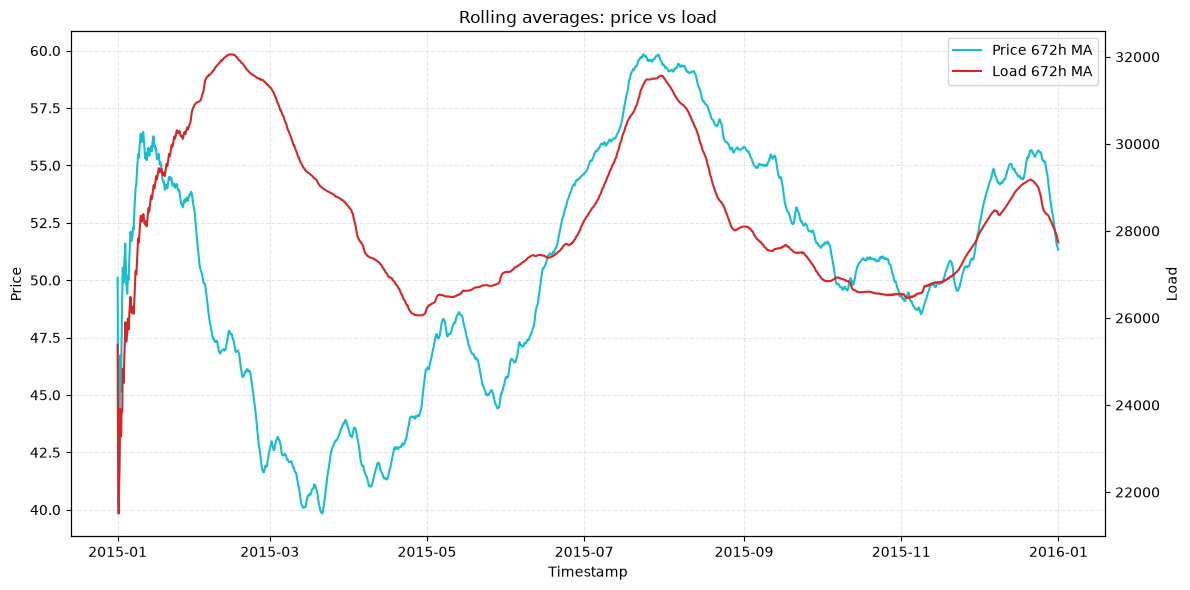

In [10]:
price_col = prices_2015.select_dtypes(include="number").columns[0]
load_col = load_2015.select_dtypes(include="number").columns[0]


rolling_window = 24*28
ma_price_col = f"{price_col}_MA{rolling_window}"
prices_2015[ma_price_col] = prices_2015[price_col].rolling(window=rolling_window, min_periods=1).mean()

ma_load_col = f"{load_col}_MA{rolling_window}"
load_2015[ma_load_col] = load_2015[load_col].rolling(window=rolling_window, min_periods=1).mean()

fig, ax_price = plt.subplots(figsize=(12, 6))
line_price_ma, = ax_price.plot(prices_2015["Timestamp"], prices_2015[ma_price_col],
                               color="tab:cyan", linestyle="-", label=f"{price_col} {rolling_window}h MA")
ax_price.set_ylabel("Price")

ax_load = ax_price.twinx()
line_load_ma, = ax_load.plot(load_2015["Timestamp"], load_2015[ma_load_col],
                             color="tab:red", linestyle="-", label=f"{load_col} {rolling_window}h MA")
ax_load.set_ylabel("Load")

ax_price.set_title(f"Rolling averages: price vs load")
ax_price.set_xlabel("Timestamp")
ax_price.grid(True, linestyle="--", alpha=0.3)

lines = [line_price_ma, line_load_ma]
ax_price.legend(lines, [line.get_label() for line in lines], loc="best")

plt.tight_layout()

## Full time series

In [11]:
prices = pd.concat([
    pd.read_csv(os.path.join(PRICE_PATH, f'Spain_ENTSO-E_{year}.csv'))
    for year in range(2015, 2025)
], ignore_index=True)
prices['Timestamp'] = pd.to_datetime(prices['Timestamp'])
prices.rename(columns={'Spain': 'Price'}, inplace=True)
display(prices.head(2))
print("...")
display(prices.tail(2))

,Timestamp,Price
0,2015-01-01 00:00:00,50.1
1,2015-01-01 01:00:00,48.1


...


,Timestamp,Price
85558,2024-10-04 22:00:00,117.17
85559,2024-10-04 23:00:00,115.00


In [12]:
load = pd.concat([
    pd.read_csv(os.path.join(LOAD_PATH, f'Spain_ENTSO-E_{year}.csv'))
    for year in range(2015, 2025)
], ignore_index=True)
load['Timestamp'] = pd.to_datetime(load['Timestamp'])
load.rename(columns={'Spain': 'Load'}, inplace=True)
display(load.head(2))
print("...")
display(load.tail(2))

,Timestamp,Load
0,2015-01-01 00:00:00,25385.0
1,2015-01-01 01:00:00,24382.0


...


,Timestamp,Load
156371,2024-12-31 23:30:00,24192.0
156372,2024-12-31 23:45:00,23888.0


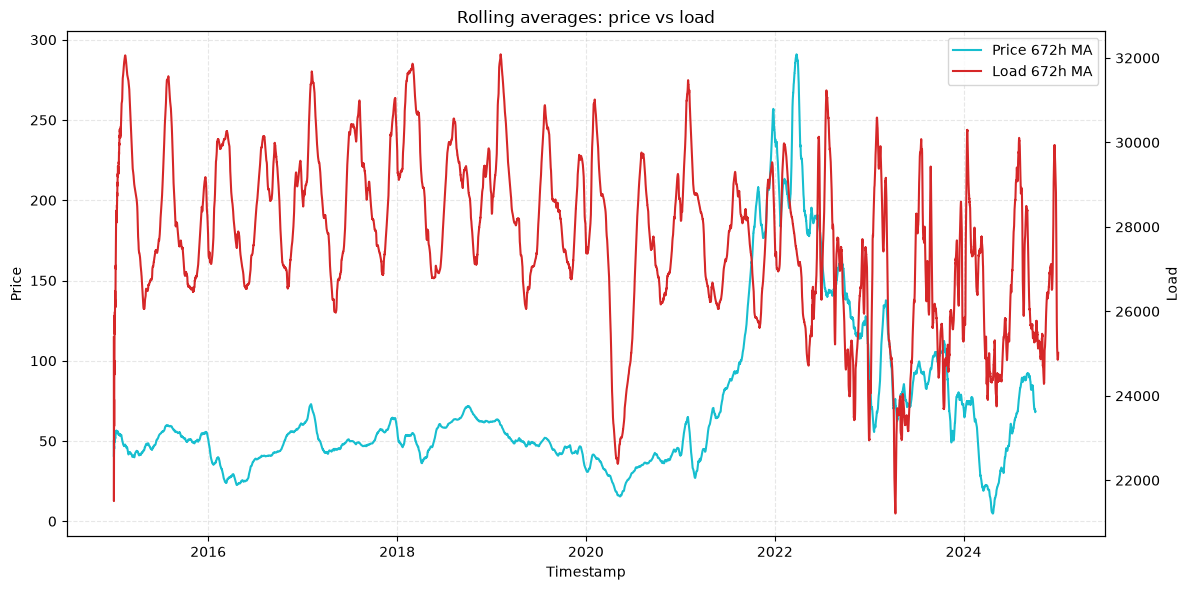

In [ ]:
price_col = prices.select_dtypes(include="number").columns[0]
load_col = load.select_dtypes(include="number").columns[0]

rolling_window = 24*28
ma_price_col = f"{price_col}_MA{rolling_window}"
prices[ma_price_col] = prices[price_col].rolling(window=rolling_window, min_periods=1).mean()

ma_load_col = f"{load_col}_MA{rolling_window}"
load[ma_load_col] = load[load_col].rolling(window=rolling_window, min_periods=1).mean()

fig, ax_price = plt.subplots(figsize=(12, 6))
line_price_ma, = ax_price.plot(prices["Timestamp"], prices[ma_price_col],
                               color="tab:cyan", linestyle="-", label=f"{price_col} {rolling_window}h MA")
ax_price.set_ylabel("Price")

ax_load = ax_price.twinx()
line_load_ma, = ax_load.plot(load["Timestamp"], load[ma_load_col],
                             color="tab:red", linestyle="-", label=f"{load_col} {rolling_window}h MA")
ax_load.set_ylabel("Load")

ax_price.set_title(f"Elctricity price and load")
ax_price.set_xlabel("Timestamp")
ax_price.grid(True, linestyle="--", alpha=0.3)

lines = [line_price_ma, line_load_ma]
ax_price.legend(lines, [line.get_label() for line in lines], loc="best")

plt.tight_layout()